# Step 1 — Targeted EDA: monthly variables vs. target

Before implementing `build_monthly_trend_features()` in `src/features.py`, we need to
validate with real data whether the monthly trends (m1 -> m6) actually relate to
`liquidity_stress_next_30d`. See `RESOURCES.md` for why (lesson from Home Credit:
well-targeted feature engineering matters more than model tuning).

This notebook uses the functions from `src/` instead of rewriting the data loading,
as recommended in the README.

**Cell 1**: imports and data loading.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, data, features, model, evaluate

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

train, test = data.load_raw_data()
print("train:", train.shape, "| test:", test.shape)
train.head()

train: (40000, 184) | test: (30000, 183)


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

**Cell 2**: group the monthly columns by family (`m1_..m6_`) to find out
how many trend variables need to be built and confirm that all 6 months
exist for every family.

In [2]:
import re

monthly_cols = [c for c in train.columns if re.match(r"^m[1-6]_", c)]
col_set = set(monthly_cols)

# strip the m1_..m6_ prefix to group by variable family
families = sorted(set(re.sub(r"^m[1-6]_", "", c) for c in monthly_cols))

print(f"{len(monthly_cols)} monthly columns -> {len(families)} variable families\n")
for fam in families:
    months_present = [m for m in range(1, 7) if f"m{m}_{fam}" in col_set]
    print(f"{fam:35s} months present: {months_present}")

174 monthly columns -> 29 variable families

daily_avg_bal                       months present: [1, 2, 3, 4, 5, 6]
deposit_agents                      months present: [1, 2, 3, 4, 5, 6]
deposit_highest_amount              months present: [1, 2, 3, 4, 5, 6]
deposit_total_value                 months present: [1, 2, 3, 4, 5, 6]
deposit_volume                      months present: [1, 2, 3, 4, 5, 6]
merchantpay_highest_amount          months present: [1, 2, 3, 4, 5, 6]
merchantpay_merchants               months present: [1, 2, 3, 4, 5, 6]
merchantpay_total_value             months present: [1, 2, 3, 4, 5, 6]
merchantpay_volume                  months present: [1, 2, 3, 4, 5, 6]
mm_send_highest_amount              months present: [1, 2, 3, 4, 5, 6]
mm_send_recipients                  months present: [1, 2, 3, 4, 5, 6]
mm_send_total_value                 months present: [1, 2, 3, 4, 5, 6]
mm_send_volume                      months present: [1, 2, 3, 4, 5, 6]
paybill_companies               

**Cell 3**: compare how each family evolves chronologically — from 6 months ago
(`m6`, oldest) up to the most recent month (`m1`) — split by target. Per
`data_dictionary.csv`, **m1 is the most recent month and m6 is the oldest**, so
the x-axis is plotted in reverse (`ax.invert_xaxis()`) to read left-to-right as
oldest -> most recent, like a normal time series. We're looking to see whether
customers with `liquidity_stress_next_30d = 1` show a different trend (e.g.
average balance dropping, withdrawals rising) as they approach the prediction
point, compared to those who don't.

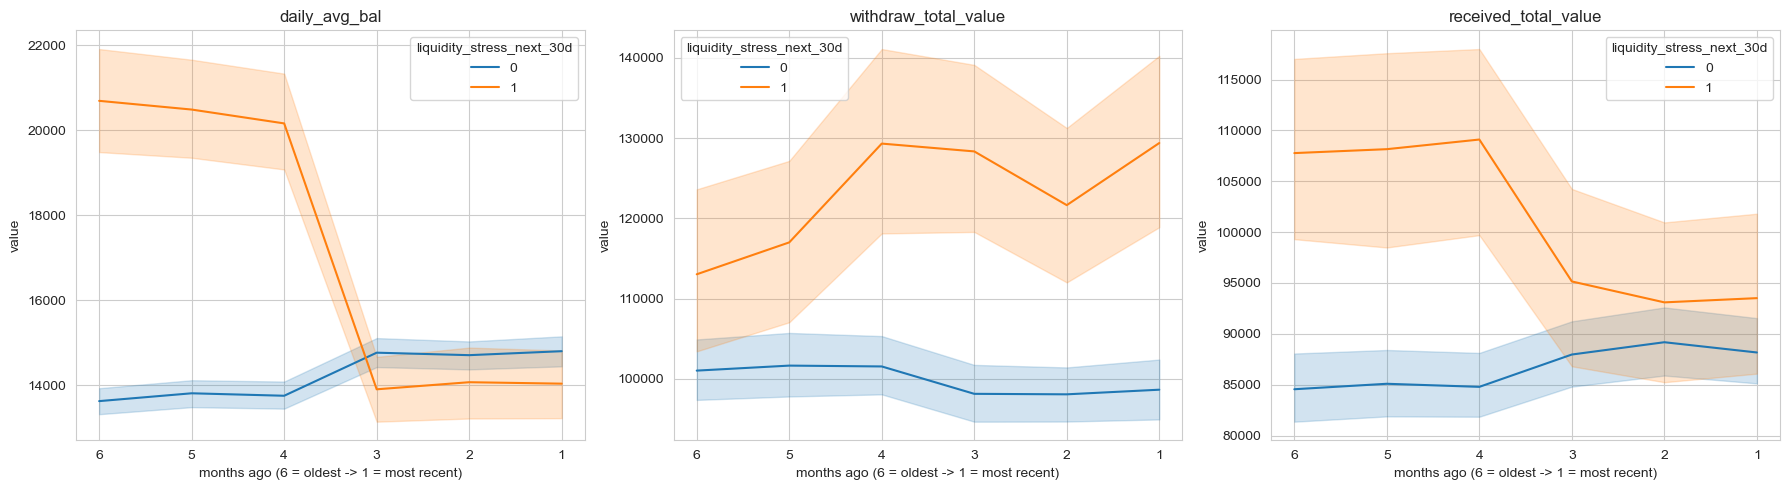

% change m6 (6 months ago) -> m1 (most recent) by target group:

daily_avg_bal             [mean    ] target=0:    +8.6%   target=1:   -32.2%
daily_avg_bal             [median  ] target=0:    +5.9%   target=1:   -26.1%

withdraw_total_value      [mean    ] target=0:    -2.4%   target=1:   +14.5%
withdraw_total_value      [median  ] target=0:   -14.8%   target=1:  +115.8%

received_total_value      [mean    ] target=0:    +4.3%   target=1:   -13.2%
received_total_value      [median  ] target=0:   +28.7%   target=1:   -74.1%



In [3]:
key_families = ["daily_avg_bal", "withdraw_total_value", "received_total_value"]

# 1 row x 3 columns of subplots, one per variable family
fig, axes = plt.subplots(1, len(key_families), figsize=(18, 5))

for ax, fam in zip(axes, key_families):
    # step a: build the 6 monthly column names for this family
    # (e.g. for "daily_avg_bal" -> m1_daily_avg_bal, m2_daily_avg_bal, ..., m6_daily_avg_bal)
    cols = [f"m{m}_{fam}" for m in range(1, 7)]

    # step b: keep only those 6 columns + the target
    plot_df = train[cols + [config.TARGET]].copy()

    # step c: go from "wide" (6 columns, one per month) to "long" (1 "month" column + 1 "value" column)
    # this is needed because seaborn.lineplot expects an x column and a y column, not 6 separate columns
    plot_df = plot_df.melt(id_vars=config.TARGET, value_vars=cols, var_name="month", value_name="value")

    # step d: extract the month number from the column name. IMPORTANT (confirmed in
    # data_dictionary.csv): m1 is the MOST RECENT month and m6 is the OLDEST month, so this
    # number is really "how many months ago" -- not a normal forward-counting month index.
    plot_df["months_ago"] = plot_df["month"].str.extract(r"m(\d)_").astype(int)

    # step e: plot months_ago on the x-axis, then invert the axis. matplotlib draws ascending
    # values left-to-right by default, so without inverting, "1 month ago" (most recent) would
    # sit to the LEFT of "6 months ago" (oldest) -- i.e. the chart would read backwards in time.
    # invert_xaxis() flips that so the chart reads left-to-right as oldest -> most recent,
    # like a normal time series.
    sns.lineplot(data=plot_df, x="months_ago", y="value", hue=config.TARGET, estimator="mean", ax=ax)
    ax.invert_xaxis()
    ax.set_title(fam)
    ax.set_xlabel("months ago (6 = oldest -> 1 = most recent)")

plt.tight_layout()
plt.show()

# --- numeric readout: the numbers behind what the chart shows ---
# % change from 6 months ago (m6, oldest) to the most recent month (m1) -- i.e. the actual
# chronological trend as the customer approaches the prediction point. We use both mean AND
# median because these financial variables tend to have strong outliers that can distort
# the mean; if mean and median tell the same story, the pattern is more trustworthy.
print("% change m6 (6 months ago) -> m1 (most recent) by target group:\n")
for fam in key_families:
    m1_col, m6_col = f"m1_{fam}", f"m6_{fam}"
    for stat_name, stat_fn in [("mean", "mean"), ("median", "median")]:
        # mean (or median) of m1 and m6, computed separately for target=0 and target=1
        grouped = train.groupby(config.TARGET)[[m1_col, m6_col]].agg(stat_fn)
        # % change: (most_recent - oldest) / oldest * 100
        pct_change = (grouped[m1_col] - grouped[m6_col]) / grouped[m6_col] * 100
        t0 = pct_change.get(0, float("nan"))
        t1 = pct_change.get(1, float("nan"))
        print(f"{fam:25s} [{stat_name:8s}] target=0: {t0:+7.1f}%   target=1: {t1:+7.1f}%")
    print()

## Step 2 — Rank all 29 families by trend signal strength

Cell 3 validated the trend signal on 3 hand-picked families. Now let's check
**all 29 families systematically**: for each one, compute the raw month-to-month
delta (`m1 - m6`, most recent minus oldest) and measure how well that single
number alone predicts the target using ROC-AUC. Ranking by distance from 0.5
tells us which families carry the strongest simple trend signal, so we know
which ones to prioritize first when implementing `build_monthly_trend_features()`
in `src/features.py`.

**Source:** this delta-based trend feature (`m1 - m6`, most recent minus oldest)
follows the "delta between last and first value" technique from the American
Express – Default Prediction competition writeups (see `RESOURCES.md`), which
reported ~12% improvement using this class of feature.

In [4]:
from sklearn.metrics import roc_auc_score

# step a: for each family, compute the raw delta (most recent - oldest, i.e. m1 - m6).
# we use the raw difference (not a % change) to sidestep division-by-zero issues:
# several families (e.g. deposit_volume, mm_send_volume) can be exactly 0 in a given
# month, which would make a percentage change undefined or infinite.
results = []
for fam in families:
    m1_col, m6_col = f"m1_{fam}", f"m6_{fam}"
    delta = train[m1_col] - train[m6_col]

    # step b: roc_auc_score can't handle missing values, so drop rows where the delta is NaN
    mask = delta.notna()
    if mask.sum() < 100:
        continue

    # step c: ROC-AUC of this single raw number against the target tells us how well
    # it alone separates target=0 from target=1 -- it's scale-invariant (only depends
    # on ranking), so we don't need to normalize the delta first.
    auc = roc_auc_score(train.loc[mask, config.TARGET], delta[mask])

    # step d: an AUC of 0.5 means no separating power at all. AUC below 0.5 means the
    # relationship is inverted (higher delta -> lower target probability) but is just
    # as informative as one above 0.5 -- so we rank by distance from 0.5, not by AUC itself.
    results.append((fam, auc, abs(auc - 0.5)))

signal_ranking = pd.DataFrame(results, columns=["family", "auc", "signal_strength"])
signal_ranking = signal_ranking.sort_values("signal_strength", ascending=False).reset_index(drop=True)

print("Top 10 families by trend signal strength (|AUC - 0.5|):\n")
print(signal_ranking.head(10).to_string(index=False))
print("\nBottom 5 (weakest signal):\n")
print(signal_ranking.tail(5).to_string(index=False))

Top 10 families by trend signal strength (|AUC - 0.5|):

                 family      auc  signal_strength
          daily_avg_bal 0.382313         0.117687
    deposit_total_value 0.433812         0.066188
         deposit_volume 0.435696         0.064304
         deposit_agents 0.448030         0.051970
 deposit_highest_amount 0.449090         0.050910
        withdraw_volume 0.548203         0.048203
   received_total_value 0.452536         0.047464
        received_volume 0.454659         0.045341
withdraw_highest_amount 0.541273         0.041273
   withdraw_total_value 0.541126         0.041126

Bottom 5 (weakest signal):

                family      auc  signal_strength
paybill_highest_amount 0.510401         0.010401
        mm_send_volume 0.504401         0.004401
   mm_send_total_value 0.502821         0.002821
    mm_send_recipients 0.502753         0.002753
mm_send_highest_amount 0.502134         0.002134


**Cell 5**: build the trend features for the top families and sanity-check them.

We select the top families from `signal_ranking` (Cell 4) and build 4 trend
features per family: `delta_m1_m6`, `mean_6m`, `std_6m`, `ratio_m1_mean`. As a
sanity check, we compute the standalone AUC of each new feature against the
target — the `*_delta_m1_m6` AUCs should roughly match what we already saw in
Cell 4.

**Source:** aggregation set (mean/std/last + delta/ratio) follows the American
Express – Default Prediction technique documented in `RESOURCES.md`.

In [5]:
from sklearn.metrics import roc_auc_score

# NOTE: since build_monthly_trend_features() was just added to src/features.py,
# restart the kernel (or re-run the "from src import ..." cell) so this
# picks up the new function -- Python caches modules on first import.

top_families = signal_ranking.head(13)["family"].tolist()
print("Top families selected:", top_families)

trend_features = features.build_monthly_trend_features(train, top_families)
print("shape:", trend_features.shape)
print()

for col in trend_features.columns:
    mask = trend_features[col].notna()
    auc = roc_auc_score(train.loc[mask, config.TARGET], trend_features.loc[mask, col])
    print(f"{col:35s} AUC={auc:.4f}")

Top families selected: ['daily_avg_bal', 'deposit_total_value', 'deposit_volume', 'deposit_agents', 'deposit_highest_amount', 'withdraw_volume', 'received_total_value', 'received_volume', 'withdraw_highest_amount', 'withdraw_total_value', 'received_senders', 'withdraw_agents', 'received_highest_amount']
shape: (40000, 91)

daily_avg_bal_delta_m1_m6           AUC=0.3823
daily_avg_bal_mean_6m               AUC=0.4851
daily_avg_bal_std_6m                AUC=0.5090
daily_avg_bal_min_6m                AUC=0.4620
daily_avg_bal_max_6m                AUC=0.5038
daily_avg_bal_ratio_m1_mean         AUC=0.3888
daily_avg_bal_weighted_mean_6m      AUC=0.4478
deposit_total_value_delta_m1_m6     AUC=0.4338
deposit_total_value_mean_6m         AUC=0.4502
deposit_total_value_std_6m          AUC=0.4598
deposit_total_value_min_6m          AUC=0.4939
deposit_total_value_max_6m          AUC=0.4593
deposit_total_value_ratio_m1_mean   AUC=0.4235
deposit_total_value_weighted_mean_6m AUC=0.4285
deposit_volume_d

## Step 3 — Does the trend feature engineering actually help?

Before permanently changing `src/train.py`, let's quantify the improvement:
train the same baseline Logistic Regression twice — once with only the
current one-hot encoded features, once adding the 13-family trend features
from Cell 5 — and compare `combined_score`.

**Source:** this "measure before committing to the pipeline" approach follows
the Home Credit Default Risk lesson documented in `RESOURCES.md` — feature
engineering should be validated on its own merit before investing in model
tuning.

In [6]:
from sklearn.model_selection import train_test_split

# baseline: same one-hot encoded features src/train.py uses today
feature_cols = features.get_feature_columns(train, config.ID_COL, config.TARGET)
X_baseline, test_baseline = features.encode_features(train, test, feature_cols)
X_baseline, test_baseline = features.impute_missing(X_baseline, test_baseline)

# enhanced: baseline + trend features for the top 13 families (Cell 4/5)
trend_train = features.build_monthly_trend_features(train, top_families)
trend_test = features.build_monthly_trend_features(test, top_families)
X_enhanced = pd.concat([X_baseline, trend_train], axis=1)
test_enhanced = pd.concat([test_baseline, trend_test], axis=1)
X_enhanced, test_enhanced = features.impute_missing(X_enhanced, test_enhanced)

y = train[config.TARGET]

def evaluate_variant(X, y, label):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
    )
    pipeline = model.build_logreg_pipeline(class_weight=None)
    pipeline.fit(X_train, y_train)
    val_pred_prob = pipeline.predict_proba(X_val)[:, 1]
    scores = evaluate.combined_score(y_val, val_pred_prob)
    evaluate.print_scores(scores, label=label)
    return scores

baseline_scores = evaluate_variant(X_baseline, y, "Baseline (no trend features)")
enhanced_scores = evaluate_variant(X_enhanced, y, "Enhanced (+ trend features)")

print(f"\nCombined score improvement: {baseline_scores['combined_score'] - enhanced_scores['combined_score']:+.5f} (positive = better)")

--- Baseline (no trend features) ---
Log Loss      : 0.37764
ROC-AUC       : 0.75077
Combined score: 0.32628 (lower is better)
--- Enhanced (+ trend features) ---
Log Loss      : 0.36477
ROC-AUC       : 0.77448
Combined score: 0.30907 (lower is better)

Combined score improvement: +0.01721 (positive = better)


## Step 4 — Logistic Regression vs LightGBM

**Source:** LightGBM/XGBoost ensembles were the winning approach in the Amex
Default Prediction and Home Credit Default Risk competitions (see
RESOURCES.md). We compare it against Logistic Regression on the same
enhanced feature set (baseline + trend features) validated in Step 3.

In [7]:
def evaluate_pipeline(X, y, label, pipeline_builder):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
    )
    pipeline = pipeline_builder(class_weight=None)
    pipeline.fit(X_train, y_train)
    val_pred_prob = pipeline.predict_proba(X_val)[:, 1]
    scores = evaluate.combined_score(y_val, val_pred_prob)
    evaluate.print_scores(scores, label=label)
    return scores

logreg_scores = evaluate_pipeline(X_enhanced, y, "Logistic Regression (+ trend features)", model.build_logreg_pipeline)
lightgbm_scores = evaluate_pipeline(X_enhanced, y, "LightGBM (+ trend features)", model.build_lightgbm_pipeline)

print(f"\nCombined score improvement (LogReg -> LightGBM): {logreg_scores['combined_score'] - lightgbm_scores['combined_score']:+.5f} (positive = better)")

--- Logistic Regression (+ trend features) ---
Log Loss      : 0.36477
ROC-AUC       : 0.77448
Combined score: 0.30907 (lower is better)
--- LightGBM (+ trend features) ---
Log Loss      : 0.28905
ROC-AUC       : 0.87272
Combined score: 0.22435 (lower is better)

Combined score improvement (LogReg -> LightGBM): +0.08472 (positive = better)


## Step 5 — Probability calibration (CalibratedClassifierCV)

**Source:** Niculescu-Mizil & Caruana, "Predicting Good Probabilities with
Supervised Learning" (ICML 2005, see RESOURCES.md) — boosted trees like
LightGBM push probability mass away from 0 and 1 (good ranking, poorly
calibrated output); Platt scaling (`method="sigmoid"`) corrects this. Since
Log Loss carries 60% of this competition's combined score, this targets
that weight directly. Compared using the same Stratified K-Fold CV adopted
in `src/train.py`, on the enhanced feature set (baseline + trend features).

In [8]:
raw_cv = evaluate.cross_validate_score(
    lambda: model.build_lightgbm_pipeline(class_weight=None),
    X_enhanced, y,
    n_splits=config.CV_FOLDS,
    random_state=config.RANDOM_STATE,
)
evaluate.print_cv_summary(raw_cv)

calibrated_cv = evaluate.cross_validate_score(
    lambda: model.build_lightgbm_calibrated_pipeline(class_weight=None),
    X_enhanced, y,
    n_splits=config.CV_FOLDS,
    random_state=config.RANDOM_STATE,
)
evaluate.print_cv_summary(calibrated_cv)

print(f"\nCombined score improvement (raw -> calibrated): {raw_cv['combined_score_mean']
- calibrated_cv['combined_score_mean']:+.5f} (positive = better)")

--- Fold 1/5 ---
Log Loss      : 0.27679
ROC-AUC       : 0.88700
Combined score: 0.21127 (lower is better)
--- Fold 2/5 ---
Log Loss      : 0.28217
ROC-AUC       : 0.87948
Combined score: 0.21751 (lower is better)
--- Fold 3/5 ---
Log Loss      : 0.28638
ROC-AUC       : 0.87970
Combined score: 0.21995 (lower is better)
--- Fold 4/5 ---
Log Loss      : 0.28530
ROC-AUC       : 0.87614
Combined score: 0.22072 (lower is better)
--- Fold 5/5 ---
Log Loss      : 0.28558
ROC-AUC       : 0.87222
Combined score: 0.22246 (lower is better)
--- Cross-validation summary ---
Log Loss      : 0.28324 +/- 0.00353
ROC-AUC       : 0.87891 +/- 0.00488
Combined score: 0.21838 +/- 0.00390 (lower is better)
--- Fold 1/5 ---
Log Loss      : 0.27019
ROC-AUC       : 0.88923
Combined score: 0.20642 (lower is better)
--- Fold 2/5 ---
Log Loss      : 0.27279
ROC-AUC       : 0.88596
Combined score: 0.20929 (lower is better)
--- Fold 3/5 ---
Log Loss      : 0.27744
ROC-AUC       : 0.88280
Combined score: 0.21334 (lo

## Step 7 — Tune LightGBM hyperparameters (random search)

**Source:** LightGBM's official "Parameters Tuning" docs (see RESOURCES.md)
describe the num_leaves / learning_rate / num_iterations trade-offs;
Bergstra & Bengio (JMLR 2012, see RESOURCES.md) show random search matches
or beats grid search for the same compute budget, since only a subset of
hyperparameters matters and that subset varies by dataset.

Random search over n_estimators, learning_rate, num_leaves, scored with
the existing `evaluate.cross_validate_score()` on the *current* feature
set (baseline one-hot + trend features), using
`model.build_lightgbm_calibrated_pipeline()` directly so the search
target matches the real competition metric. Compared against a baseline
computed in this same cell run (not the older number in README.md, since
the feature set has changed since that number was recorded).


In [10]:
import numpy as np

# Same feature set src/train.py currently builds by default.
feature_cols = features.get_feature_columns(train, config.ID_COL, config.TARGET)
X_search, _ = features.encode_features(train, test, feature_cols)
trend_search = features.build_monthly_trend_features(train, config.TOP_TREND_FAMILIES)
X_search = pd.concat([X_search, trend_search], axis=1)
X_search, _ = features.impute_missing(X_search, X_search.copy())
y = train[config.TARGET]

# Same-run baseline: LightGBM library defaults on this exact feature set.
baseline_cv = evaluate.cross_validate_score(
    lambda: model.build_lightgbm_calibrated_pipeline(class_weight=None),
    X_search, y, n_splits=config.CV_FOLDS, random_state=config.RANDOM_STATE, verbose=False,
)
print("Baseline (library defaults, current feature set):")
evaluate.print_cv_summary(baseline_cv)

N_TRIALS = 20
rng = np.random.RandomState(config.RANDOM_STATE)
n_estimators_choices = [100, 200, 300, 500, 800]
num_leaves_choices = [15, 31, 63, 127, 255]

trial_results = [{
    "n_estimators": 100, "learning_rate": 0.1, "num_leaves": 31, "is_baseline": True,
    **baseline_cv,
}]

for trial in range(N_TRIALS):
    n_estimators = int(rng.choice(n_estimators_choices))
    learning_rate = float(10 ** rng.uniform(np.log10(0.01), np.log10(0.3)))
    num_leaves = int(rng.choice(num_leaves_choices))

    cv_summary = evaluate.cross_validate_score(
        lambda: model.build_lightgbm_calibrated_pipeline(
            class_weight=None,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
        ),
        X_search, y, n_splits=config.CV_FOLDS, random_state=config.RANDOM_STATE, verbose=False,
    )
    print(f"Trial {trial + 1}/{N_TRIALS}: n_estimators={n_estimators}, "
          f"learning_rate={learning_rate:.4f}, num_leaves={num_leaves} "
          f"-> combined_score_mean={cv_summary['combined_score_mean']:.5f}")

    trial_results.append({
        "n_estimators": n_estimators, "learning_rate": learning_rate,
        "num_leaves": num_leaves, "is_baseline": False,
        **cv_summary,
    })

results_df = pd.DataFrame(trial_results).sort_values("combined_score_mean").reset_index(drop=True)
print("\nTop 5 trials (including baseline) by combined score:")
print(results_df.head(5)[["n_estimators", "learning_rate", "num_leaves", "is_baseline", "combined_score_mean", "log_loss_mean", "roc_auc_mean"]])

Baseline (library defaults, current feature set):
--- Cross-validation summary ---
Log Loss      : 0.27639 +/- 0.00435
ROC-AUC       : 0.88188 +/- 0.00578
Combined score: 0.21308 +/- 0.00488 (lower is better)
Trial 1/20: n_estimators=500, learning_rate=0.2537, num_leaves=63 -> combined_score_mean=0.21165


KeyboardInterrupt: 

In [ ]:
print(results_df.iloc[0][["n_estimators", "learning_rate", "num_leaves",
                           "combined_score_mean", "combined_score_std",
                           "log_loss_mean", "log_loss_std",
                           "roc_auc_mean", "roc_auc_std"]])

n_estimators                500
learning_rate          0.053881
num_leaves                   63
combined_score_mean    0.208148
combined_score_std     0.004054
log_loss_mean          0.270936
log_loss_std           0.003763
roc_auc_mean           0.886033
roc_auc_std            0.004571
Name: 0, dtype: object


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


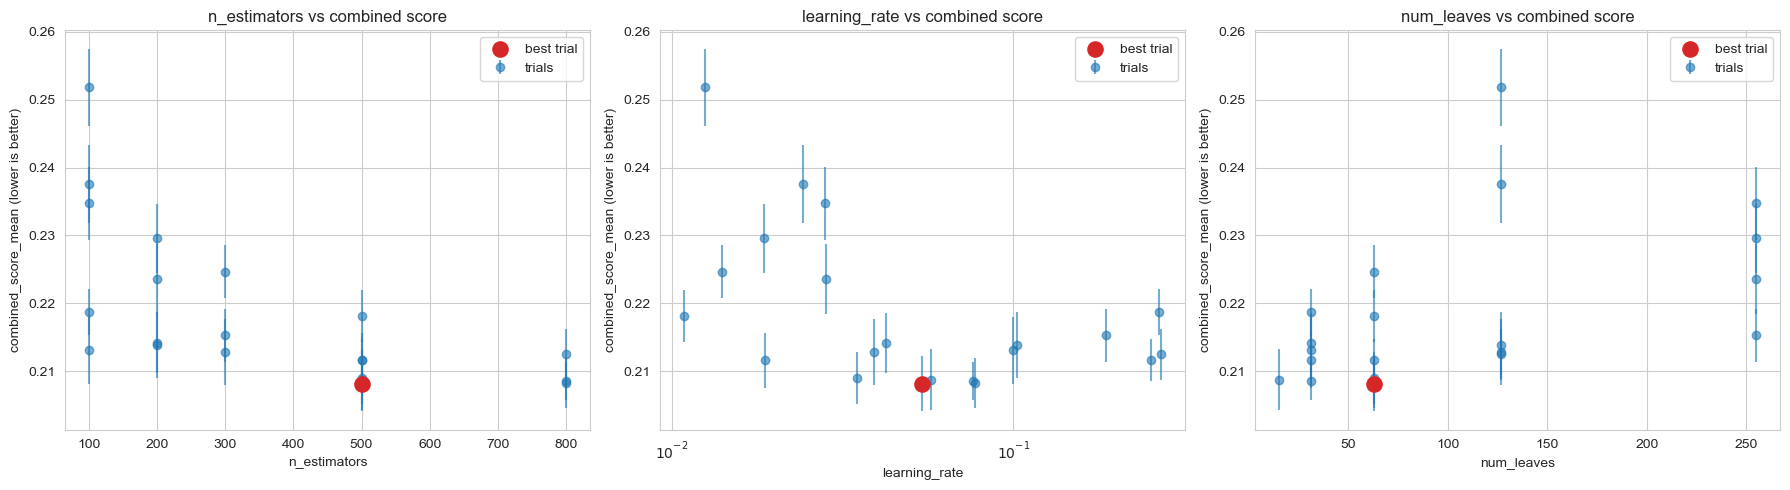

Best trial:
n_estimators                500
learning_rate          0.053881
num_leaves                   63
is_baseline               False
combined_score_mean    0.208148
combined_score_std     0.004054
log_loss_mean          0.270936
roc_auc_mean           0.886033
Name: 0, dtype: object


In [ ]:
best_idx = results_df["combined_score_mean"].idxmin()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, param in zip(axes, ["n_estimators", "learning_rate", "num_leaves"]):
    ax.errorbar(
        results_df[param], results_df["combined_score_mean"],
        yerr=results_df["combined_score_std"], fmt="o", alpha=0.6,
        color="tab:blue", ecolor="tab:blue", label="trials",
    )
    ax.scatter(
        results_df.loc[[best_idx], param], results_df.loc[[best_idx], "combined_score_mean"],
        color="tab:red", s=120, zorder=5, label="best trial",
    )
    if param == "learning_rate":
        ax.set_xscale("log")
    ax.set_xlabel(param)
    ax.set_ylabel("combined_score_mean (lower is better)")
    ax.set_title(f"{param} vs combined score")
    ax.legend()
plt.tight_layout()
plt.show()

best_trial = results_df.loc[best_idx]
print("Best trial:")
print(best_trial[["n_estimators", "learning_rate", "num_leaves", "is_baseline",
                   "combined_score_mean", "combined_score_std",
                   "log_loss_mean", "roc_auc_mean"]])

In [ ]:
# Step 7b — refined search around the best region found above
N_TRIALS_REFINED = 15
rng_refined = np.random.RandomState(config.RANDOM_STATE + 1)

n_estimators_choices_refined = [400, 500, 600, 700, 800]
num_leaves_choices_refined = [15, 31, 47, 63, 80]

refined_results = []
for trial in range(N_TRIALS_REFINED):
    n_estimators = int(rng_refined.choice(n_estimators_choices_refined))
    learning_rate = float(10 ** rng_refined.uniform(np.log10(0.03), np.log10(0.10)))
    num_leaves = int(rng_refined.choice(num_leaves_choices_refined))

    cv_summary = evaluate.cross_validate_score(
        lambda: model.build_lightgbm_calibrated_pipeline(
            class_weight=None,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
        ),
        X_search, y, n_splits=config.CV_FOLDS, random_state=config.RANDOM_STATE, verbose=False,
    )
    print(f"Refined trial {trial + 1}/{N_TRIALS_REFINED}: n_estimators={n_estimators}, "
          f"learning_rate={learning_rate:.4f}, num_leaves={num_leaves} "
          f"-> combined_score_mean={cv_summary['combined_score_mean']:.5f}")

    refined_results.append({
        "n_estimators": n_estimators, "learning_rate": learning_rate,
        "num_leaves": num_leaves, "is_baseline": False,
        **cv_summary,
    })

results_df = pd.concat([results_df, pd.DataFrame(refined_results)], ignore_index=True).sort_values("combined_score_mean").reset_index(drop=True)
print("\nTop 5 overall (broad + refined search):")
print(results_df.head(5)[["n_estimators", "learning_rate", "num_leaves", "is_baseline", "combined_score_mean", "log_loss_mean", "roc_auc_mean"]])

Refined trial 1/15: n_estimators=800, learning_rate=0.0546, num_leaves=31 -> combined_score_mean=0.20825
Refined trial 2/15: n_estimators=600, learning_rate=0.0401, num_leaves=31 -> combined_score_mean=0.20798
Refined trial 3/15: n_estimators=700, learning_rate=0.0844, num_leaves=15 -> combined_score_mean=0.20878
Refined trial 4/15: n_estimators=700, learning_rate=0.0614, num_leaves=63 -> combined_score_mean=0.20932
Refined trial 5/15: n_estimators=700, learning_rate=0.0358, num_leaves=47 -> combined_score_mean=0.20783
Refined trial 6/15: n_estimators=700, learning_rate=0.0321, num_leaves=80 -> combined_score_mean=0.20894
Refined trial 7/15: n_estimators=800, learning_rate=0.0656, num_leaves=80 -> combined_score_mean=0.20928
Refined trial 8/15: n_estimators=400, learning_rate=0.0368, num_leaves=15 -> combined_score_mean=0.21161
Refined trial 9/15: n_estimators=600, learning_rate=0.0659, num_leaves=31 -> combined_score_mean=0.20952
Refined trial 10/15: n_estimators=600, learning_rate=0.

In [ ]:
print(results_df.iloc[0][["n_estimators", "learning_rate", "num_leaves",
                           "combined_score_mean", "combined_score_std",
                           "log_loss_mean", "log_loss_std",
                           "roc_auc_mean", "roc_auc_std"]])

n_estimators                600
learning_rate          0.041141
num_leaves                   31
combined_score_mean    0.207524
combined_score_std     0.003315
log_loss_mean          0.270387
log_loss_std           0.002913
roc_auc_mean           0.886771
roc_auc_std            0.004017
Name: 0, dtype: object


## Note on later experiments (not kept in this notebook)

After this tuning round, four further experiments were tried and
**rejected** (worse on Log Loss and/or ROC-AUC vs. the 0.20752 baseline
above): `class_weight="balanced"`, an unweighted LightGBM+XGBoost
ensemble, a weighted-ensemble grid search, and standalone XGBoost
hyperparameter tuning. Their code was pruned from this notebook to keep
it focused on what actually improved the pipeline; the full numbers,
reasoning, and sources for each are in `README.md`'s Progress log and in
`docs/superpowers/specs/` (one design doc per experiment, dated
2026-07-31). `src/train.py` still uses the single tuned LightGBM
pipeline from Step 7/7b above.